In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from pathlib import Path

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid')

plt.rcParams['font.family'] = 'Malgun Gothic' 
plt.rcParams['axes.unicode_minus'] = False 

In [2]:
import gc
from src.data_loader import load_data

In [3]:
df = load_data()

gc.collect()

if not df.empty:
    print(f"Final Data Count: {len(df):,}")
    print(df.info())

Final Data Count: 28,165,708
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28165708 entries, 0 to 28165707
Data columns (total 7 columns):
 #   Column        Dtype         
---  ------        -----         
 0   started_at    datetime64[ns]
 1   ended_at      datetime64[ns]
 2   start_lat     float32       
 3   start_lng     float32       
 4   end_lat       float32       
 5   end_lng       float32       
 6   duration_min  float32       
dtypes: datetime64[ns](2), float32(5)
memory usage: 967.0 MB
None


In [4]:
df['started_at'] = pd.to_datetime(df['started_at'])
df['ended_at']   = pd.to_datetime(df['ended_at'])

print(len(df))

28165708


In [5]:
# 이용 시간
# 이상치 제거
df['duration_min'] = (df['ended_at'] - df['started_at']).dt.total_seconds() / 60

before = len(df)
df = df[(df['duration_min'] > 0) & (df['duration_min'] <= 180)].copy()
print(f'이상치 제거: {before:,} → {len(df):,} (제거 {before - len(df):,}건)')

이상치 제거: 28,165,708 → 28,165,708 (제거 0건)


In [6]:
# 시간 피처
df['hour']       = df['started_at'].dt.hour
df['dayofweek']  = df['started_at'].dt.dayofweek   # 0=Mon, 6=Sun
df['month']      = df['started_at'].dt.month
df['date']       = df['started_at'].dt.date
df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)

def time_of_day(h):
    if 6 <= h < 10:    return 'morning_rush'
    elif 10 <= h < 16: return 'daytime'
    elif 16 <= h < 20: return 'evening_rush'
    else:              return 'night'

df['time_of_day'] = df['hour'].apply(time_of_day)

print(df[['hour', 'dayofweek', 'month', 'is_weekend', 'time_of_day']].head())

   hour  dayofweek  month  is_weekend   time_of_day
0    15          5      4           1       daytime
1     8          2      4           0  morning_rush
2    11          1      4           0       daytime
3     9          1      4           0  morning_rush
4    11          2      4           0       daytime


In [7]:
# 이동 거리 (Haversine) 
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlam = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlam/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

df['distance_km'] = haversine(
    df['start_lat'], df['start_lng'],
    df['end_lat'],   df['end_lng']
)

print(df['distance_km'].describe().round(3))

count    2.808817e+07
mean     2.079000e+00
std      3.566000e+00
min      0.000000e+00
25%      8.820000e-01
50%      1.557000e+00
75%      2.725000e+00
max      8.661509e+03
Name: distance_km, dtype: float64


In [8]:
# 시간별 수요 집계 
hourly_demand = (
    df.groupby(['date', 'hour'])
      .size()
      .reset_index(name='ride_count')
)
hourly_demand['datetime'] = pd.to_datetime(
    hourly_demand['date'].astype(str) + ' ' +
    hourly_demand['hour'].astype(str) + ':00'
)
hourly_demand = hourly_demand.sort_values('datetime').reset_index(drop=True)

print(hourly_demand.shape)
hourly_demand.head(10)

(4394, 4)


,date,hour,ride_count,datetime
0,2025-03-31,22,1,2025-03-31 22:00:00
1,2025-03-31,23,62,2025-03-31 23:00:00
2,2025-04-01,0,268,2025-04-01 00:00:00
3,2025-04-01,1,175,2025-04-01 01:00:00
4,2025-04-01,2,141,2025-04-01 02:00:00
5,2025-04-01,3,119,2025-04-01 03:00:00
6,2025-04-01,4,262,2025-04-01 04:00:00
7,2025-04-01,5,1055,2025-04-01 05:00:00
8,2025-04-01,6,3084,2025-04-01 06:00:00
9,2025-04-01,7,6888,2025-04-01 07:00:00


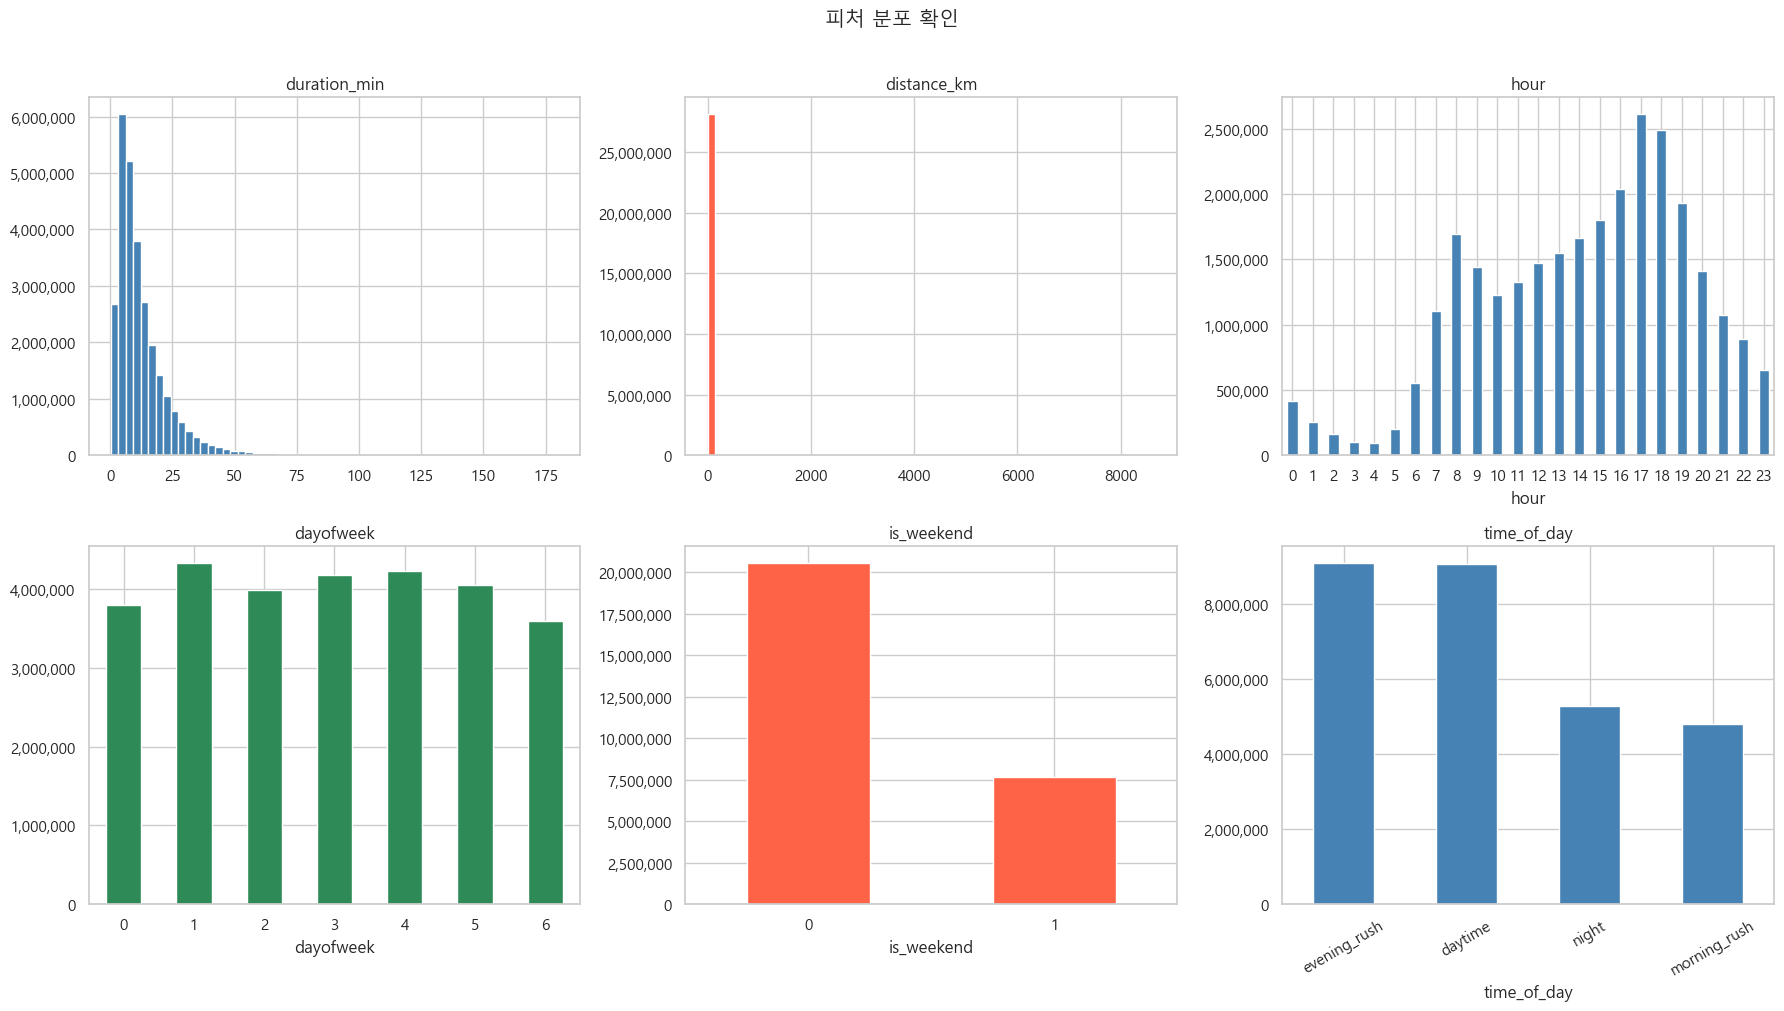

In [9]:
# 피처 분포 
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

df['duration_min'].hist(bins=60, ax=axes[0][0], color='steelblue', edgecolor='white')
axes[0][0].set_title('duration_min')

df['distance_km'].hist(bins=60, ax=axes[0][1], color='tomato', edgecolor='white')
axes[0][1].set_title('distance_km')

df.groupby('hour').size().plot(kind='bar', ax=axes[0][2], color='steelblue', edgecolor='white')
axes[0][2].set_title('hour')
axes[0][2].tick_params(axis='x', rotation=0)

df.groupby('dayofweek').size().plot(kind='bar', ax=axes[1][0], color='seagreen', edgecolor='white')
axes[1][0].set_title('dayofweek')
axes[1][0].tick_params(axis='x', rotation=0)

df['is_weekend'].value_counts().plot(kind='bar', ax=axes[1][1], color='tomato', edgecolor='white')
axes[1][1].set_title('is_weekend')
axes[1][1].tick_params(axis='x', rotation=0)

df['time_of_day'].value_counts().plot(kind='bar', ax=axes[1][2], color='steelblue', edgecolor='white')
axes[1][2].set_title('time_of_day')
axes[1][2].tick_params(axis='x', rotation=30)

for ax in axes.flatten():
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('피처 분포 확인', y=1.01)
plt.tight_layout()
plt.show()

In [10]:
out_dir = Path('..') / 'data' / 'processed'
df.to_parquet(out_dir / 'citibike_featured.parquet', index=False)
hourly_demand.to_parquet(out_dir / 'hourly_demand.parquet', index=False)
